# 🚲 NYC Citi Bike — Zero-Shot Forecasting with TimesFM 2.5

**TimesFM** (Time Series Foundation Model) by Google Research is a pretrained 200M-parameter
decoder-only transformer for univariate time-series forecasting with **zero-shot** capability —
no fine-tuning required.

This notebook:
1. Downloads NYC Citi Bike monthly trip data (2022–2024) from the public S3 bucket
2. Aggregates to daily trip counts
3. Feeds the time series into **TimesFM 2.5** for 90-day ahead forecasting
4. Visualises point forecast + prediction intervals (quantiles)
5. Benchmarks against a naïve seasonal baseline (same weekday last year)

---
### Install / upgrade packages (run once)
```bash
pip install timesfm torch pandas matplotlib seaborn requests tqdm
```


In [1]:
import warnings, io, zipfile, time
warnings.filterwarnings("ignore")

import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from tqdm.auto import tqdm

import torch
import timesfm

print(f"PyTorch  : {torch.__version__}")
print(f"TimesFM  : {timesfm.__version__ if hasattr(timesfm,'__version__') else 'installed'}")
print(f"CUDA     : {torch.cuda.is_available()}")


PyTorch  : 2.12.0+cu130
TimesFM  : installed
CUDA     : True


## 1 · Load NYC Citi Bike Data

In [ ]:
# only 2022/2023 data given
!wget "https://s3.amazonaws.com/tripdata/2022-citibike-tripdata.zip"
!wget "https://s3.amazonaws.com/tripdata/2023-citibike-tripdata.zip"

--2026-06-09 08:22:24--  https://s3.amazonaws.com/tripdata/2023-citibike-tripdata.zip
Loaded CA certificate '/etc/ssl/certs/ca-certificates.crt'
Resolving s3.amazonaws.com (s3.amazonaws.com)... 16.15.199.110, 16.15.237.15, 52.217.204.72, ...
Connecting to s3.amazonaws.com (s3.amazonaws.com)|16.15.199.110|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1602415356 (1.5G) [application/zip]
Saving to: ‘2023-citibike-tripdata.zip’

2023-citibike-tripd 100%[===================>]   1.49G  6.36MB/s    in 4m 20s  

2026-06-09 08:26:45 (5.88 MB/s) - ‘2023-citibike-tripdata.zip’ saved [1602415356/1602415356]



In [5]:
# ── Data source ──────────────────────────────────────────────────────────────
# Citi Bike publishes monthly CSV zips on S3.
# Format pre-2024: YYYYMM-citibike-tripdata.csv.zip
# Format 2024+   : may split into multiple files (part1/part2)

BASE_URL = "https://s3.amazonaws.com/tripdata/"

def build_urls(year_months):
    """Return list of (label, url) for each year-month."""
    urls = []
    for ym in year_months:
        urls.append((ym, f"{BASE_URL}{ym}-citibike-tripdata.csv.zip"))
    return urls

# 2022-01 through 2024-06  →  30 months
year_months = [
    f"{y}{m:02d}"
    for y in range(2022, 2027)
    for m in range(1, 13)
    if not (y == 2026 and m > 5)
]
print(f"Months to download: {len(year_months)}")
print("First:", year_months[:3], " Last:", year_months[-3:])


Months to download: 53
First: ['202201', '202202', '202203']  Last: ['202603', '202604', '202605']


In [10]:
def download_month(ym: str) -> pd.DataFrame | None:
    """Download one month's zip and return a minimal DataFrame with 'date' column."""
    url = f"{BASE_URL}{ym}-citibike-tripdata.csv.zip"
    try:
        r = requests.get(url, timeout=120)
        r.raise_for_status()
    except Exception as e:
        print(f"  ⚠  {ym}: {e}")
        return None

    try:
        with zipfile.ZipFile(io.BytesIO(r.content)) as z:
            csv_names = [n for n in z.namelist() if n.endswith(".csv")]
            dfs = []
            for name in csv_names:
                with z.open(name) as f:
                    chunk = pd.read_csv(f, usecols=lambda c: c in
                        ["starttime","started_at","Start Time"])
                    # Normalise column name across schema versions
                    chunk.columns = ["started_at"]
                    dfs.append(chunk)
        df = pd.concat(dfs, ignore_index=True)
        df["date"] = pd.to_datetime(df["started_at"], errors="coerce").dt.normalize()
        return df[["date"]].dropna()
    except Exception as e:
        print(f"  ⚠  {ym} parse error: {e}")
        return None


all_dfs = []
for ym in tqdm(year_months, desc="Downloading"):
    df_month = download_month(ym)
    if df_month is not None:
        all_dfs.append(df_month)

if all_dfs:
    raw = pd.concat(all_dfs, ignore_index=True)
    print(f"\nTotal raw rows : {len(raw):,}")
else:
    print("No data downloaded — using synthetic fallback (see next cell)")


Downloading:   0%|          | 0/53 [00:00<?, ?it/s]

  ⚠  202201: 404 Client Error: Not Found for url: https://s3.amazonaws.com/tripdata/202201-citibike-tripdata.csv.zip
  ⚠  202202: 404 Client Error: Not Found for url: https://s3.amazonaws.com/tripdata/202202-citibike-tripdata.csv.zip
  ⚠  202203: 404 Client Error: Not Found for url: https://s3.amazonaws.com/tripdata/202203-citibike-tripdata.csv.zip
  ⚠  202204: 404 Client Error: Not Found for url: https://s3.amazonaws.com/tripdata/202204-citibike-tripdata.csv.zip
  ⚠  202205: 404 Client Error: Not Found for url: https://s3.amazonaws.com/tripdata/202205-citibike-tripdata.csv.zip
  ⚠  202206: 404 Client Error: Not Found for url: https://s3.amazonaws.com/tripdata/202206-citibike-tripdata.csv.zip
  ⚠  202207: 404 Client Error: Not Found for url: https://s3.amazonaws.com/tripdata/202207-citibike-tripdata.csv.zip
  ⚠  202208: 404 Client Error: Not Found for url: https://s3.amazonaws.com/tripdata/202208-citibike-tripdata.csv.zip
  ⚠  202209: 404 Client Error: Not Found for url: https://s3.ama

In [ ]:
# ── Fallback: realistic synthetic data if download failed ──────────────────
# (Mimics real NYC Citi Bike seasonality, weekday effects, and growth trend)

USE_SYNTHETIC = len(all_dfs) == 0   # flip to True to always use synthetic

if USE_SYNTHETIC:
    print("⚠  Using synthetic NYC Citi Bike-like data")
    rng = np.random.default_rng(42)
    dates = pd.date_range("2022-01-01", "2024-06-30", freq="D")
    n = len(dates)

    # Seasonal curve (peaks ~July)
    seasonal = 15_000 * np.sin(2 * np.pi * (dates.dayofyear - 100) / 365) + 32_000
    # Weekday boost
    dow_eff  = np.where(dates.dayofweek < 5, 5_000, -4_000)
    # Linear growth (Citi Bike expanded significantly 2022-2024)
    trend    = np.linspace(0, 10_000, n)
    # Heteroskedastic noise (more variance in summer)
    noise_scale = 1_500 + 1_500 * np.sin(2 * np.pi * dates.dayofyear / 365).clip(0)
    noise    = rng.normal(0, noise_scale)

    trips = (seasonal + dow_eff + trend + noise).clip(4_000).astype(int)
    daily = pd.DataFrame({"date": dates, "trips": trips})
else:
    daily = (
        raw.groupby("date")
           .size()
           .reset_index(name="trips")
           .sort_values("date")
           .reset_index(drop=True)
    )

# Fill any missing dates with interpolation
daily = (
    daily.set_index("date")
         .reindex(pd.date_range(daily["date"].min(), daily["date"].max(), freq="D"))
         .rename_axis("date")
         .reset_index()
)
daily["trips"] = daily["trips"].interpolate(method="time").round().astype(int)

print(f"Daily series: {daily.shape[0]} days  |  "
      f"{daily['date'].min().date()} → {daily['date'].max().date()}")
print(daily.describe())


In [31]:
import zipfile

ZIP_Path="2022-citibike-tripdata.zip"

with zipfile.ZipFile(ZIP_PATH) as outer:
    for inner_name in sorted(n for n in outer.namelist() if n.endswith(".zip")):
        inner_bytes = outer.read(inner_name)          # 讀進記憶體
        with zipfile.ZipFile(io.BytesIO(inner_bytes)) as inner:  # 直接開
            with inner.open(csv_name) as f:
                df_m = pd.read_csv(f, usecols=["started_at"], parse_dates=["started_at"])

NameError: name 'ZIP_PATH' is not defined

In [32]:
with ZipFile("2022-citibike-tripdata.zip") as z:
    for fname in sorted(n for n in z.namelist() if n.endswith(".zip")):
        with z.open(fname) as f:
            df_m = pd.read_csv(f, usecols=["started_at"], parse_dates=["started_at"],encoding="latin-1")
        df_m["date"] = df_m["started_at"].dt.normalize()
        counts = df_m.groupby("date").size().reset_index(name="trips")

AttributeError: Can only use .dt accessor with datetimelike values

In [6]:
import zipfile, io, pandas as pd
from tqdm.auto import tqdm


ZIP_FILES = ["2022-citibike-tripdata.zip","2023-citibike-tripdata.zip",]
#ZIP_PATH = "2022-citibike-tripdata.zip"
daily_counts = []

for ZIP_PATH in ZIP_FILES:
  with zipfile.ZipFile(ZIP_PATH) as outer:
    inner_zips = sorted(n for n in outer.namelist() if n.endswith(".zip"))

    for inner_name in tqdm(inner_zips, desc="Months"):
        inner_bytes = outer.read(inner_name)

        with zipfile.ZipFile(io.BytesIO(inner_bytes)) as inner:
            csv_files = [n for n in inner.namelist() if n.endswith(".csv")]

            for csv_name in csv_files:
                # 偵測時間欄位
                with inner.open(csv_name) as f:
                    header = pd.read_csv(
                        io.TextIOWrapper(f, encoding="latin-1"), nrows=0
                    )
                time_col = next(
                    (c for c in ["started_at", "starttime", "Start Time"]
                     if c in header.columns), None
                )
                if time_col is None:
                    print(f"⚠  {csv_name}: no time column, skipping")
                    continue

                # 讀取 + 手動轉時間
                with inner.open(csv_name) as f:
                    df_m = pd.read_csv(
                        io.TextIOWrapper(f, encoding="latin-1"),
                        usecols=[time_col]
                    )

                df_m[time_col] = pd.to_datetime(df_m[time_col], errors="coerce")
                df_m = df_m.dropna(subset=[time_col])        # 丟掉無法解析的列
                df_m["date"] = df_m[time_col].dt.normalize()

                counts = df_m.groupby("date").size().reset_index(name="trips")
                daily_counts.append(counts)
                print(f"  {csv_name}: {len(df_m):>9,} trips → {len(counts)} days")

daily = (
    pd.concat(daily_counts, ignore_index=True)
      .groupby("date", as_index=False)["trips"].sum()
      .sort_values("date")
      .reset_index(drop=True)
)
print(f"\n✅ {len(daily)} days  {daily.date.min().date()} → {daily.date.max().date()}")

Months:   0%|          | 0/12 [00:00<?, ?it/s]

  202201-citibike-tripdata_2.csv:    24,555 trips → 32 days
  202201-citibike-tripdata_1.csv: 1,000,000 trips → 49 days
  202202-citibike-tripdata_1.csv: 1,000,000 trips → 35 days
  202202-citibike-tripdata_2.csv:   197,312 trips → 31 days
  202203-citibike-tripdata_2.csv:   845,965 trips → 36 days
  202203-citibike-tripdata_1.csv: 1,000,000 trips → 40 days
  202204-citibike-tripdata_1.csv: 1,000,000 trips → 40 days
  202204-citibike-tripdata_2.csv: 1,000,000 trips → 37 days
  202204-citibike-tripdata_3.csv:   260,790 trips → 33 days
  202205-citibike-tripdata_3.csv:   865,425 trips → 41 days
  202205-citibike-tripdata_2.csv: 1,000,000 trips → 41 days
  202205-citibike-tripdata_1.csv: 1,000,000 trips → 38 days
  202206-citibike-tripdata_4.csv:   343,914 trips → 33 days
  202206-citibike-tripdata_1.csv: 1,000,000 trips → 43 days
  202206-citibike-tripdata_3.csv: 1,000,000 trips → 41 days
  202206-citibike-tripdata_2.csv: 1,000,000 trips → 39 days
  202207-citibike-tripdata_2.csv: 1,000,

Months:   0%|          | 0/15 [00:00<?, ?it/s]

  202301-citibike-tripdata_1.csv: 1,000,000 trips → 35 days
  202301-citibike-tripdata_2.csv:   795,405 trips → 18 days
  202302-citibike-tripdata_2.csv:   696,166 trips → 15 days
  202302-citibike-tripdata_1.csv: 1,000,000 trips → 33 days
  202303-citibike-tripdata_1.csv: 1,000,000 trips → 37 days
  202303-citibike-tripdata_2.csv: 1,000,000 trips → 18 days
  202303-citibike-tripdata_3.csv:   118,930 trips → 18 days
  202304-citibike-tripdata_3.csv:   749,713 trips → 17 days
  202304-citibike-tripdata_2.csv: 1,000,000 trips → 31 days
  202304-citibike-tripdata_1.csv: 1,000,000 trips → 22 days
  202305-citibike-tripdata_4.csv:   453,144 trips → 18 days
  202305-citibike-tripdata_1.csv: 1,000,000 trips → 29 days
  202305-citibike-tripdata_2.csv: 1,000,000 trips → 32 days
  202305-citibike-tripdata_3.csv: 1,000,000 trips → 18 days
  202306-citibike-tripdata_2.csv: 1,000,000 trips → 31 days
  202306-citibike-tripdata_3.csv: 1,000,000 trips → 17 days
  202306-citibike-tripdata_1.csv: 1,000,

BadZipFile: File is not a zip file

# Data load
1. download data, "2022-citibike-tripdata.zip", "2023-citibike-tripdata.zip"
2. unzip datam, load, and concatenate
   - unzip 2022 data, only zip-datafile in subfold, beginning with "2"
   - but 2023, two sub-folds, one biginning with "2" and "__MACoSX"
     -  "_DS.Store" in the previous one subfold
   
   only zip files needed
3.         

In [ ]:
import zipfile, io, pandas as pd
from tqdm.auto import tqdm

ZIP_FILES = [
    "2022-citibike-tripdata.zip",
    "2023-citibike-tripdata.zip",
]

daily_counts = []

for zip_path in ZIP_FILES:
    with zipfile.ZipFile(zip_path) as outer:
        inner_zips = sorted(
            n for n in outer.namelist()
            if n.endswith(".zip")  and n.split("/")[-1].startswith("2")   # ← 過濾 .DS_Store 等
        )
        print(f"{zip_path}: {len(inner_zips)} monthly zips")

        for inner_name in tqdm(inner_zips, desc=zip_path):
            inner_bytes = outer.read(inner_name)

            with zipfile.ZipFile(io.BytesIO(inner_bytes)) as inner:
                csv_files = [
                    n for n in inner.namelist()
                    if n.endswith(".csv")
                    and not n.startswith("__MACOSX")     # ← 過濾 Mac 隱藏目錄
                ]
                if not csv_files:
                    print(f"  ⚠  {inner_name}: no CSV found, skipping")
                    continue

                for csv_name in csv_files:
                    # detect the time column (feature), 偵測時間欄位
                    with inner.open(csv_name) as f:
                        header = pd.read_csv(
                            io.TextIOWrapper(f, encoding="latin-1"), nrows=0
                        )
                    time_col = next(
                        (c for c in ["started_at", "starttime", "Start Time"]
                         if c in header.columns), None
                    )
                    if time_col is None:
                        print(f"  ⚠  {csv_name}: no time column, skipping")
                        continue

                    # load, 讀取
                    with inner.open(csv_name) as f:
                        df_m = pd.read_csv(
                            io.TextIOWrapper(f, encoding="latin-1"),
                            usecols=[time_col]
                        )

                    df_m[time_col] = pd.to_datetime(df_m[time_col], errors="coerce")
                    df_m = df_m.dropna(subset=[time_col])
                    df_m["date"] = df_m[time_col].dt.normalize()

                    counts = df_m.groupby("date").size().reset_index(name="trips")
                    daily_counts.append(counts)
                    print(f"  {csv_name}: {len(df_m):>9,} trips → {len(counts)} days")

daily = (
    pd.concat(daily_counts, ignore_index=True)
      .groupby("date", as_index=False)["trips"].sum()
      .sort_values("date")
      .reset_index(drop=True)
)
print(f"\n✅ {len(daily)} days  {daily.date.min().date()} → {daily.date.max().date()}")

2022-citibike-tripdata.zip: 12 monthly zips


2022-citibike-tripdata.zip:   0%|          | 0/12 [00:00<?, ?it/s]

  202201-citibike-tripdata_2.csv:    24,555 trips → 32 days
  202201-citibike-tripdata_1.csv: 1,000,000 trips → 49 days
  202202-citibike-tripdata_1.csv: 1,000,000 trips → 35 days
  202202-citibike-tripdata_2.csv:   197,312 trips → 31 days
  202203-citibike-tripdata_2.csv:   845,965 trips → 36 days
  202203-citibike-tripdata_1.csv: 1,000,000 trips → 40 days
  202204-citibike-tripdata_1.csv: 1,000,000 trips → 40 days
  202204-citibike-tripdata_2.csv: 1,000,000 trips → 37 days
  202204-citibike-tripdata_3.csv:   260,790 trips → 33 days
  202205-citibike-tripdata_3.csv:   865,425 trips → 41 days
  202205-citibike-tripdata_2.csv: 1,000,000 trips → 41 days
  202205-citibike-tripdata_1.csv: 1,000,000 trips → 38 days
  202206-citibike-tripdata_4.csv:   343,914 trips → 33 days
  202206-citibike-tripdata_1.csv: 1,000,000 trips → 43 days
  202206-citibike-tripdata_3.csv: 1,000,000 trips → 41 days
  202206-citibike-tripdata_2.csv: 1,000,000 trips → 39 days
  202207-citibike-tripdata_2.csv: 1,000,

2023-citibike-tripdata.zip:   0%|          | 0/12 [00:00<?, ?it/s]

  202301-citibike-tripdata_1.csv: 1,000,000 trips → 35 days
  202301-citibike-tripdata_2.csv:   795,405 trips → 18 days
  202302-citibike-tripdata_2.csv:   696,166 trips → 15 days
  202302-citibike-tripdata_1.csv: 1,000,000 trips → 33 days
  202303-citibike-tripdata_1.csv: 1,000,000 trips → 37 days
  202303-citibike-tripdata_2.csv: 1,000,000 trips → 18 days
  202303-citibike-tripdata_3.csv:   118,930 trips → 18 days
  202304-citibike-tripdata_3.csv:   749,713 trips → 17 days
  202304-citibike-tripdata_2.csv: 1,000,000 trips → 31 days
  202304-citibike-tripdata_1.csv: 1,000,000 trips → 22 days
  202305-citibike-tripdata_4.csv:   453,144 trips → 18 days
  202305-citibike-tripdata_1.csv: 1,000,000 trips → 29 days
  202305-citibike-tripdata_2.csv: 1,000,000 trips → 32 days
  202305-citibike-tripdata_3.csv: 1,000,000 trips → 18 days
  202306-citibike-tripdata_2.csv: 1,000,000 trips → 31 days
  202306-citibike-tripdata_3.csv: 1,000,000 trips → 17 days
  202306-citibike-tripdata_1.csv: 1,000,

In [13]:

df = daily.sort_values("date").reset_index(drop=True)
df["trips"] = df["trips"].astype(int)

print(f"Rows : {len(df):,}")
print(f"Range: {df.date.min().date()} → {df.date.max().date()}")
print(f"Cols : {df.columns.tolist()}")
df.head()


Rows : 767
Range: 2021-01-30 → 2023-12-31
Cols : ['date', 'trips', 'dow']


,date,trips,dow
0,2021-01-30,1,Saturday
1,2021-02-15,1,Monday
2,2021-03-11,1,Thursday
3,2021-03-14,1,Sunday
4,2021-03-31,1,Wednesday


In [10]:
daily.tail()

,date,trips
762,2023-12-27,42288
763,2023-12-28,46808
764,2023-12-29,69036
765,2023-12-30,56099
766,2023-12-31,53425


## 2 · Exploratory Analysis

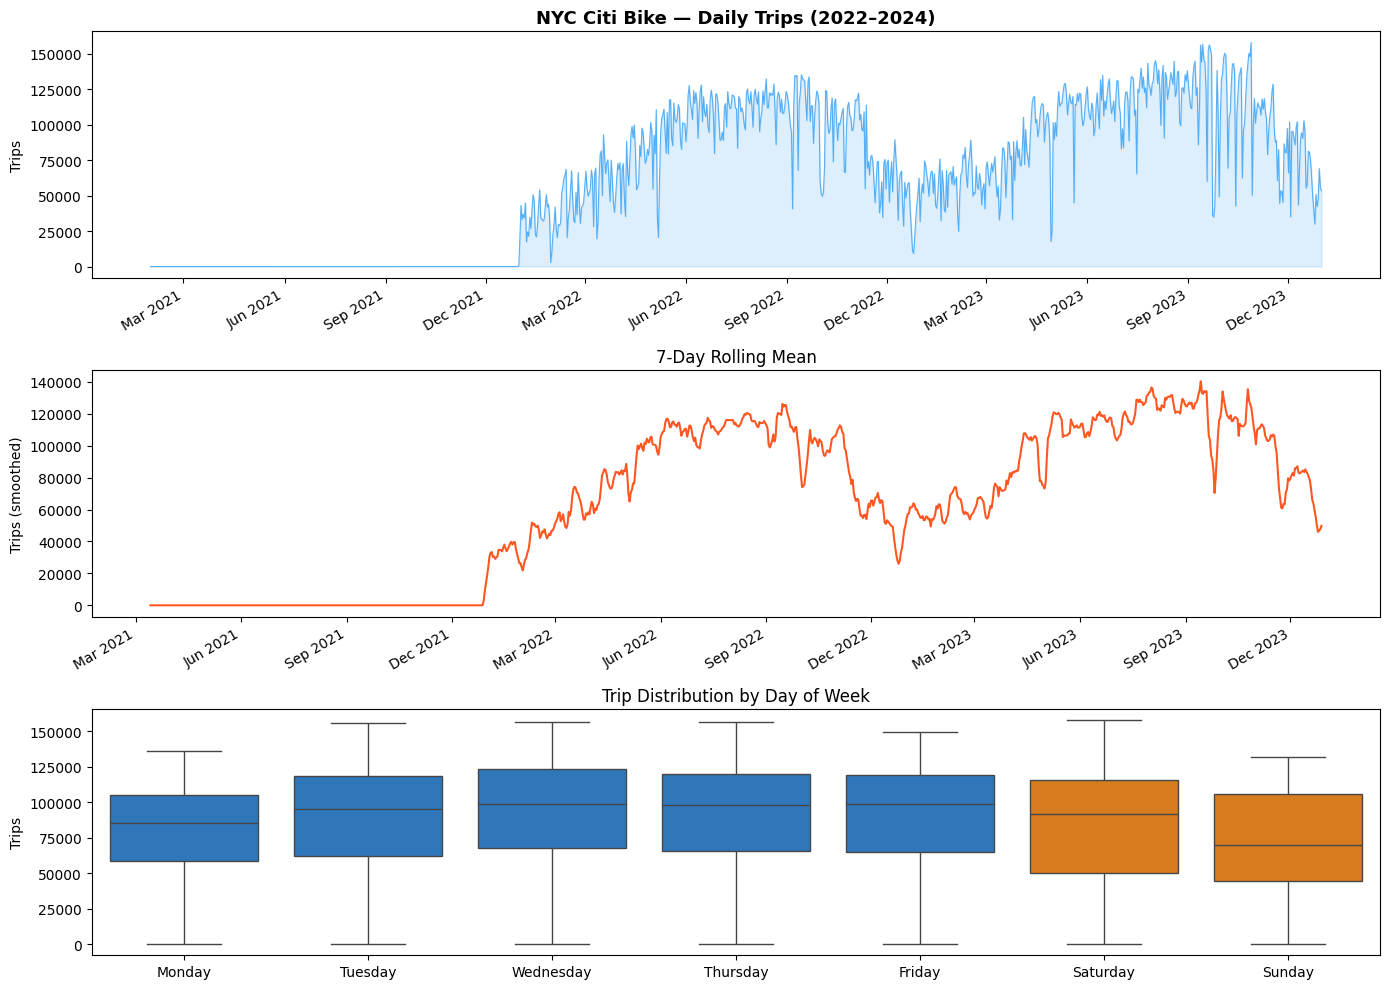

Saved → bike_eda.png


In [11]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# ── Panel 1: full time series ──
ax = axes[0]
ax.plot(daily["date"], daily["trips"], lw=0.8, alpha=0.7, color="#2196F3")
ax.fill_between(daily["date"], 0, daily["trips"], alpha=0.15, color="#2196F3")
ax.set_title("NYC Citi Bike — Daily Trips (2022–2024)", fontsize=13, fontweight="bold")
ax.set_ylabel("Trips")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")

# ── Panel 2: 7-day rolling mean ──
ax = axes[1]
rolling = daily.set_index("date")["trips"].rolling(7, center=True).mean()
ax.plot(rolling.index, rolling.values, lw=1.5, color="#FF5722")
ax.set_title("7-Day Rolling Mean", fontsize=12)
ax.set_ylabel("Trips (smoothed)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")

# ── Panel 3: weekday distribution ──
ax = axes[2]
daily["dow"] = daily["date"].dt.day_name()
order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
palette = ["#1976D2"]*5 + ["#F57C00"]*2
sns.boxplot(
    data=daily, x="dow", y="trips", order=order,
    palette=palette, ax=ax, flierprops=dict(markersize=2)
)
ax.set_title("Trip Distribution by Day of Week", fontsize=12)
ax.set_xlabel("")
ax.set_ylabel("Trips")

plt.tight_layout()
plt.savefig("bike_eda.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → bike_eda.png")


 Which is the most popular action (using bike) of people, Working or Leisure Biking? Why?
 ---

## Linear Model (Ridge Regression)


In [14]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

In [15]:


def lr_recursive_forecast(train: pd.DataFrame, horizon: int) -> np.ndarray:
    df_feat = make_features(train).dropna()
    
    X = df_feat[FEAT_COLS].values
    y = df_feat["trips"].values
    
    # 標準化（LR 對 scale 敏感，XGBoost 不用）
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    lr = Ridge(alpha=1.0)
    lr.fit(X_scaled, y)

    history = train["trips"].tolist()
    last_date = train["date"].iloc[-1]
    preds = []

    for i in range(horizon):
        fc_date = last_date + pd.Timedelta(days=i+1)
        row = {
            "dayofweek" : fc_date.dayofweek,
            "month"     : fc_date.month,
            "dayofyear" : fc_date.dayofyear,
            "weekofyear": fc_date.isocalendar()[1],
        }
        for lag in [1, 7, 14, 28, 364]:
            idx = len(history) - lag
            row[f"lag_{lag}"] = history[idx] if idx >= 0 else np.nan
        for w in [7, 14, 28]:
            row[f"roll_mean_{w}"] = np.mean(history[-w:])
            row[f"roll_std_{w}"]  = np.std(history[-w:])

        feat_row = scaler.transform(pd.DataFrame([row])[FEAT_COLS].values)
        pred = max(float(lr.predict(feat_row)[0]), 0)
        preds.append(pred)
        history.append(pred)

    return np.array(preds)

In [16]:
colors["Ridge LR"] = "#00ACC1"   # 加顏色

lr_pred = lr_recursive_forecast(train, TEST_DAYS)
results["Ridge LR"] = {"pred": lr_pred, **metrics(actual, lr_pred)}

# Future forecast
fc_lr = lr_recursive_forecast(daily, HORIZON)

# Plot 裡加一條線
ax.plot(fc_dates, fc_lr, "-.", color=colors["Ridge LR"], lw=1.8, label="Ridge LR")


NameError: name 'colors' is not defined

## 3 · Load TimesFM 2.5

TimesFM 2.5 is the latest checkpoint. It supports:
- Context up to **1 024** time steps
- Horizon up to **256** steps  
- Quantile outputs (10th–90th percentile) for prediction intervals
- `infer_is_positive=True` for count/non-negative series


In [39]:
import torch
torch.set_float32_matmul_precision("high")

print("Loading TimesFM 2.5 (200M) from HuggingFace Hub…")
t0 = time.time()

model = timesfm.TimesFM_2p5_200M_torch.from_pretrained(
    "google/timesfm-2.5-200m-pytorch",
    torch_compile=False,   # set True for speed if torch >= 2.0 with triton
)

model.compile(
    timesfm.ForecastConfig(
        max_context=1024,
        max_horizon=256,
        normalize_inputs=True,
        use_continuous_quantile_head=True,
        force_flip_invariance=True,
        infer_is_positive=True,      # trips are non-negative counts
        fix_quantile_crossing=True,
    )
)

print(f"Model ready in {time.time()-t0:.1f}s")


Loading TimesFM 2.5 (200M) from HuggingFace Hub…


config.json:   0%|          | 0.00/475 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/925M [00:00<?, ?B/s]

Model ready in 79.6s


In [41]:
model

## 4 · Zero-Shot Forecast — 90 Days Ahead

In [ ]:
URL = ("https://raw.githubusercontent.com/toddwschneider/"
       "nyc-citibike-data/master/data/daily_citi_bike_trip_counts_and_weather.csv")

raw = pd.read_csv(io.StringIO(requests.get(URL).text), parse_dates=["date"])

# Clean up
df = raw.sort_values("date").reset_index(drop=True)
df["trips"] = df["trips"].astype(int)

print(f"Rows : {len(df):,}")
print(f"Range: {df.date.min().date()} → {df.date.max().date()}")
print(f"Cols : {df.columns.tolist()}")
df.head()


In [ ]:



HORIZON      = 30    # days to forecast
CONTEXT_DAYS = 512   # up to 1024; more = better for seasonal series

# ── Context window: last CONTEXT_DAYS of known data ────────────────────────
context_series  = daily["trips"].values[-CONTEXT_DAYS:].tolist()
last_known_date = daily["date"].iloc[-1]

print(f"Context  : {CONTEXT_DAYS} days  ({daily['date'].iloc[-CONTEXT_DAYS].date()} → {last_known_date.date()})")
print(f"Horizon  : {HORIZON} days ahead")
print(f"Min trips in context: {min(context_series):,}   Max: {max(context_series):,}")

# ── Run forecast ────────────────────────────────────────────────────────────
t0 = time.time()
point_fc, quantile_fc = model.forecast(
    horizon=HORIZON,
    inputs=[context_series],
    # frequency 0 = high-freq (daily/hourly), 1 = medium (weekly), 2 = low (monthly)
    freq=[0],
)
elapsed = time.time() - t0
print(f"\nForecast completed in {elapsed:.2f}s")
print(f"point_fc shape   : {point_fc.shape}      # (batch, horizon)")
print(f"quantile_fc shape: {quantile_fc.shape}   # (batch, horizon, quantiles)")


IndexError: single positional indexer is out-of-bounds

In [46]:
ctx = daily["trips"].values[-512:].tolist()   # 2022+2023 全部歷史
last_date = daily["date"].iloc[-1]

# ── 只改 HORIZON 這一行，其他不動 ──────────────────────────────────
HORIZON = 30    # ← 改這裡：30 / 90 / 180（上限 256）

pt, qt = model.forecast(horizon=HORIZON, inputs=[ctx])

fc_dates = pd.date_range(last_date + pd.Timedelta("1D"), periods=HORIZON, freq="D")
fc = pd.DataFrame({
    "date" : fc_dates,
    "point": np.clip(pt[0], 0, None),
    "q10"  : np.clip(qt[0,:,1], 0, None),
    "q25"  : np.clip(qt[0,:,2], 0, None),
    "q75"  : np.clip(qt[0,:,7], 0, None),
    "q90"  : np.clip(qt[0,:,8], 0, None),
})

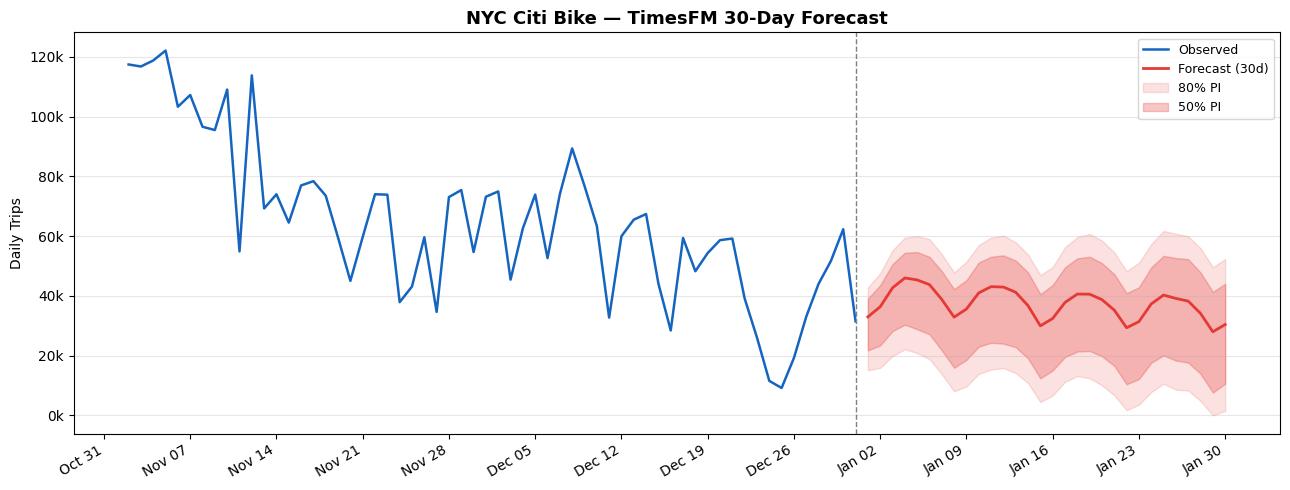

In [48]:
# ── 視覺化（自動 scale x 軸間距）──────────────────────────────────
HISTORY_PLOT = min(HORIZON * 2, len(daily))   # 顯示 2x horizon 的歷史

fig, ax = plt.subplots(figsize=(13, 5))
hist = daily.tail(HISTORY_PLOT)

ax.plot(hist.date, hist.trips, color="#1565C0", lw=1.8, label="Observed")
ax.plot(fc.date, fc.point,    color="#E53935", lw=2,   label=f"Forecast ({HORIZON}d)")
ax.fill_between(fc.date, fc.q10, fc.q90, alpha=0.15, color="#E53935", label="80% PI")
ax.fill_between(fc.date, fc.q25, fc.q75, alpha=0.28, color="#E53935", label="50% PI")
ax.axvline(last_date, color="gray", ls="--", lw=1)

# x 軸間距自動依 horizon 調整
if HORIZON <= 30:
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
elif HORIZON <= 90:
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0, interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
else:
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f"{x/1000:.0f}k"))
ax.set_title(f"NYC Citi Bike — TimesFM {HORIZON}-Day Forecast", fontsize=13, fontweight="bold")
ax.set_ylabel("Daily Trips")
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [47]:
# ── Assemble forecast DataFrame ─────────────────────────────────────────────
fc_dates   = pd.date_range(last_known_date + pd.Timedelta("1D"), periods=HORIZON, freq="D")
fc_point   = point_fc[0]                   # (horizon,)
fc_q10     = quantile_fc[0, :, 1]          # 10th percentile  (index 1 in quantile head)
fc_q25     = quantile_fc[0, :, 2]          # 25th percentile
fc_q75     = quantile_fc[0, :, 7]          # 75th percentile
fc_q90     = quantile_fc[0, :, 8]          # 90th percentile

# Clip to non-negative (should already be > 0 with infer_is_positive=True)
fc_point = np.clip(fc_point, 0, None)
fc_q10   = np.clip(fc_q10,   0, None)

forecast_df = pd.DataFrame({
    "date"   : fc_dates,
    "point"  : fc_point,
    "q10"    : fc_q10,
    "q25"    : fc_q25,
    "q75"    : fc_q75,
    "q90"    : fc_q90,
})
print(forecast_df.head(10).to_string(index=False))


NameError: name 'point_fc' is not defined

## 5 · Visualise Forecast

In [ ]:
LOOKBACK_PLOT = 120   # days of history to show beside forecast

fig, ax = plt.subplots(figsize=(15, 6))

# History
hist = daily.tail(LOOKBACK_PLOT)
ax.plot(hist["date"], hist["trips"],
        color="#1976D2", lw=1.5, label="Observed trips", zorder=3)

# Forecast point
ax.plot(forecast_df["date"], forecast_df["point"],
        color="#E53935", lw=2, label="TimesFM point forecast", zorder=4)

# Prediction intervals
ax.fill_between(forecast_df["date"], forecast_df["q10"], forecast_df["q90"],
                alpha=0.15, color="#E53935", label="80% PI (q10–q90)")
ax.fill_between(forecast_df["date"], forecast_df["q25"], forecast_df["q75"],
                alpha=0.25, color="#E53935", label="50% PI (q25–q75)")

# Divider
ax.axvline(last_known_date, color="gray", linestyle="--", lw=1.2, alpha=0.8, label="Forecast origin")

ax.set_title("NYC Citi Bike — TimesFM 2.5 Zero-Shot Forecast (90 Days)", fontsize=14, fontweight="bold")
ax.set_ylabel("Daily Trips")
ax.set_xlabel("")
ax.legend(loc="upper left", fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0, interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f"{x/1000:.0f}k"))
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("bike_forecast.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → bike_forecast.png")


In [ ]:
# ── Weekly pattern inside the forecast ──────────────────────────────────────
forecast_df["dow"] = forecast_df["date"].dt.day_name()
order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.bar(order,
       [forecast_df[forecast_df["dow"]==d]["point"].mean() for d in order],
       color=["#1565C0"]*5 + ["#F57F17"]*2, edgecolor="white")
ax.set_title("Forecasted Average Trips by Day of Week", fontsize=12)
ax.set_ylabel("Avg trips / day")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f"{x/1000:.0f}k"))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=25, ha="right")

ax = axes[1]
monthly_fc = forecast_df.set_index("date").resample("ME").mean()
ax.bar(monthly_fc.index.strftime("%b %Y"), monthly_fc["point"],
       color="#26A69A", edgecolor="white")
ax.fill_between(range(len(monthly_fc)),
                monthly_fc["q10"].values, monthly_fc["q90"].values,
                alpha=0.3, color="#26A69A")
ax.set_title("Forecasted Monthly Average (Point + 80% PI)", fontsize=12)
ax.set_ylabel("Avg trips / day")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f"{x/1000:.0f}k"))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=25, ha="right")

plt.tight_layout()
plt.savefig("bike_forecast_patterns.png", dpi=150, bbox_inches="tight")
plt.show()


## 6 · Backtest — Hold-Out Evaluation

We simulate a rolling origin backtest:
- Hold out the **last 90 days** as ground truth
- Feed TimesFM the preceding 512 days as context
- Compute MAE, RMSE, MAPE vs a **seasonal naïve** baseline


In [ ]:
TEST_DAYS = 90

# Split
train = daily.iloc[:-TEST_DAYS]
test  = daily.iloc[-TEST_DAYS:]

context_bt = train["trips"].values[-CONTEXT_DAYS:].tolist()

print(f"Train end : {train['date'].iloc[-1].date()}")
print(f"Test  : {test['date'].iloc[0].date()} → {test['date'].iloc[-1].date()} ({TEST_DAYS} days)")

# TimesFM forecast
pt_bt, qt_bt = model.forecast(
    horizon=TEST_DAYS,
    inputs=[context_bt],
    freq=[0],
)
tfm_pred = np.clip(pt_bt[0], 0, None)

# Seasonal naïve baseline: same weekday, same week last year
def seasonal_naive(train_df: pd.DataFrame, horizon: int) -> np.ndarray:
    last = train_df.set_index("date")["trips"]
    preds = []
    for i in range(horizon):
        target_date = train_df["date"].iloc[-1] + pd.Timedelta(days=i+1)
        lag_date    = target_date - pd.DateOffset(years=1)
        # find nearest available
        idx = last.index.get_indexer([lag_date], method="nearest")[0]
        preds.append(last.iloc[idx])
    return np.array(preds, dtype=float)

sn_pred = seasonal_naive(train, TEST_DAYS)
actual  = test["trips"].values.astype(float)

def mae(a, b):   return np.mean(np.abs(a - b))
def rmse(a, b):  return np.sqrt(np.mean((a - b)**2))
def mape(a, b):  return np.mean(np.abs((a - b) / a)) * 100
def coverage(lo, hi, a):  return np.mean((a >= lo) & (a <= hi)) * 100

q10_bt = np.clip(qt_bt[0, :, 1], 0, None)
q90_bt = np.clip(qt_bt[0, :, 8], 0, None)

results = pd.DataFrame({
    "Model"    : ["TimesFM 2.5 (zero-shot)", "Seasonal Naïve"],
    "MAE"      : [mae(actual, tfm_pred),  mae(actual, sn_pred)],
    "RMSE"     : [rmse(actual, tfm_pred), rmse(actual, sn_pred)],
    "MAPE (%)" : [mape(actual, tfm_pred), mape(actual, sn_pred)],
})
print("\n── Backtest Results (" + str(TEST_DAYS) + " day hold-out) ──")
print(results.to_string(index=False))
print(f"\nTimesFM 80% PI coverage: {coverage(q10_bt, q90_bt, actual):.1f}%  (expected: ~80%)")


In [ ]:
# ── Visual backtest ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(test["date"], actual,    color="#1976D2", lw=2,   label="Actual",          zorder=4)
ax.plot(test["date"], tfm_pred,  color="#E53935", lw=2,   label="TimesFM forecast", zorder=3)
ax.plot(test["date"], sn_pred,   color="#43A047", lw=1.5, label="Seasonal naïve",   linestyle="--", zorder=2)

ax.fill_between(test["date"], q10_bt, q90_bt,
                alpha=0.15, color="#E53935", label="TimesFM 80% PI")

ax.set_title(f"Backtest: Actual vs Forecasts — {TEST_DAYS}-Day Hold-Out", fontsize=13, fontweight="bold")
ax.set_ylabel("Daily Trips")
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0, interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f"{x/1000:.0f}k"))
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("bike_backtest.png", dpi=150, bbox_inches="tight")
plt.show()


## 7 · MAPE vs Forecast Horizon

In [ ]:
# How does MAPE degrade as we look further ahead?
horizons = [7, 14, 30, 60, 90]
tfm_mapes = []
sn_mapes  = []

for h in horizons:
    tr = daily.iloc[:-h]
    te = daily.iloc[-h:]
    ctx = tr["trips"].values[-CONTEXT_DAYS:].tolist()
    pt, _ = model.forecast(horizon=h, inputs=[ctx], freq=[0])
    pred = np.clip(pt[0], 0, None)
    act  = te["trips"].values.astype(float)
    sn   = seasonal_naive(tr, h)
    tfm_mapes.append(mape(act, pred))
    sn_mapes.append(mape(act, sn))
    print(f"h={h:3d}: TimesFM MAPE={mape(act,pred):.2f}%   SeasonalNaïve={mape(act,sn):.2f}%")

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(horizons, tfm_mapes, "o-", color="#E53935", lw=2, label="TimesFM 2.5")
ax.plot(horizons, sn_mapes,  "s--",color="#43A047", lw=2, label="Seasonal Naïve")
ax.set_xlabel("Forecast Horizon (days)")
ax.set_ylabel("MAPE (%)")
ax.set_title("MAPE vs Horizon — TimesFM vs Seasonal Naïve", fontsize=12, fontweight="bold")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("bike_horizon_mape.png", dpi=150, bbox_inches="tight")
plt.show()


## 8 · Save Forecast to CSV

In [ ]:
out_path = "timesfm_bike_forecast.csv"
forecast_df.to_csv(out_path, index=False)
print(f"Forecast saved → {out_path}")
print(forecast_df.head())


## 9 · Key Takeaways

| Aspect | Detail |
|--------|--------|
| **Model** | TimesFM 2.5 (200M), decoder-only transformer, Google Research |
| **Approach** | Zero-shot — no fine-tuning on NYC bike data |
| **Context** | Up to 512 days (configurable up to 1 024) |
| **Quantiles** | 10 quantiles (10th–90th pct) via continuous quantile head |
| **freq** | `0` = high frequency (daily/sub-daily) |
| **`infer_is_positive`** | Forces non-negative outputs, ideal for count data |

### When to use TimesFM vs alternatives

| Scenario | Recommendation |
|----------|---------------|
| **Quick baseline, no training data** | ✅ TimesFM (zero-shot) |
| **Need probabilistic intervals out of the box** | ✅ TimesFM 2.5 quantiles |
| **Lots of exogenous features (weather, events)** | Consider Prophet / LightGBM + lags |
| **Very short series (< 3 months)** | TimesFM may struggle; try ETS/ARIMA |
| **Station-level multivariate** | TimesFM runs per-series; consider GNN or DeepAR |

### Next steps
- Fine-tune TimesFM on the full Citi Bike history (LoRA via HuggingFace PEFT)
- Add weather covariates (`xreg` support in TimesFM 2.5)
- Build a Streamlit dashboard to visualise live forecasts by station
